=== Porównanie wariantów Gradient Descent ===

Batch GD: w = 16.5188, b = 0.0905, czas = 0.0257s
Mini-batch GD: w = 13.5046, b = 0.3489, czas = 0.4760s
Stochastic GD: w = 16.6286, b = 0.1231, czas = 0.5377s


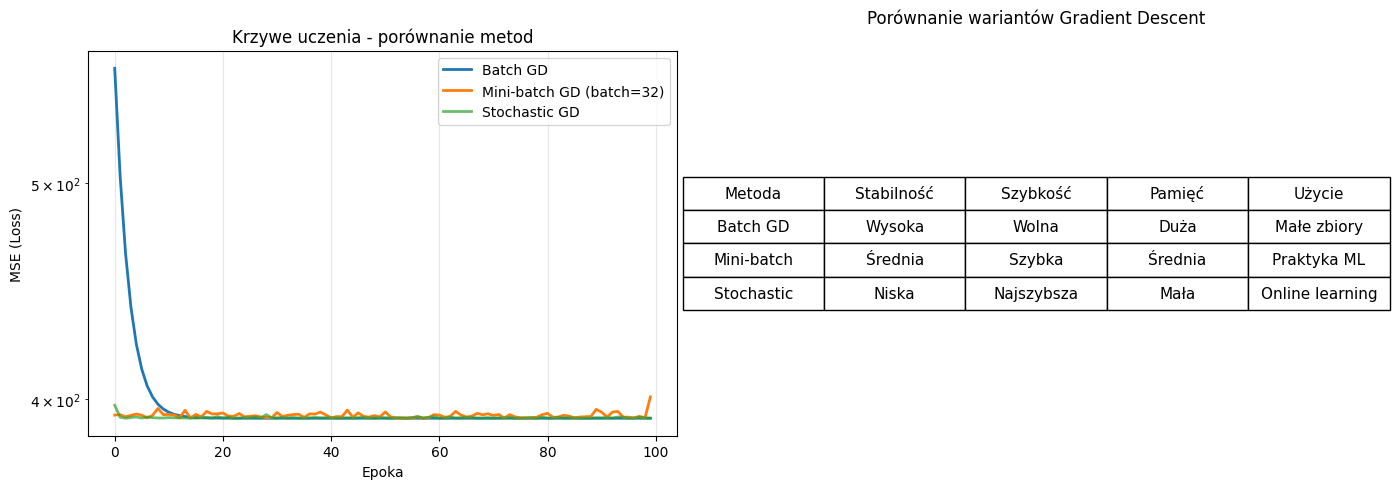

In [ ]:
# Porównanie wariantów Gradient Descent
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# Generowanie większego zbioru danych
np.random.seed(42)
X, y = make_regression(n_samples=1000, n_features=1, noise=20)
X = X.flatten()
def predict(X, w, b):
    return w * X + b

def compute_gradients_batch(X, y, w, b):
    """Gradient na całym zbiorze danych (Batch GD)"""
    n = len(y)
    y_pred = predict(X, w, b)
    error = y - y_pred
    dw = (-2/n) * np.sum(error * X)
    db = (-2/n) * np.sum(error)
    return dw, db

def batch_gradient_descent(X, y, lr=0.1, epochs=100):
    """Batch Gradient Descent - używa wszystkich danych w każdej iteracji"""
    w, b = 0.0, 0.0
    losses = []
    for epoch in range(epochs):
        dw, db = compute_gradients_batch(X, y, w, b)
        w -= lr * dw
        b -= lr * db
        loss = np.mean((y - predict(X, w, b))**2)
        losses.append(loss)
    return w, b, losses


def stochastic_gradient_descent(X, y, lr=0.01, epochs=100):
    """Stochastic GD - używa jednej obserwacji na raz"""
    w, b = 0.0, 0.0
    losses = []
    n = len(y)
    for epoch in range(epochs):
        # Losowa kolejność danych
        indices = np.random.permutation(n)
        for i in indices:
            y_pred = predict(X[i], w, b)
            error = y[i] - y_pred
            dw = -2 * error * X[i]
            db = -2 * error
            w -= lr * dw
            b -= lr * db
        loss = np.mean((y - predict(X, w, b))**2)
        losses.append(loss)
    return w, b, losses


def mini_batch_gradient_descent(X, y, lr=0.05, epochs=100, batch_size=32):
    """Mini-batch GD - używa małych porcji danych"""
    w, b = 0.0, 0.0
    losses = []
    n = len(y)
    for epoch in range(epochs):
        # Losowa kolejność danych
        indices = np.random.permutation(n)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        # Podziel na mini-batche
        for i in range(0, n, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            # Gradient na mini-batchu
            y_pred = predict(X_batch, w, b)
            error = y_batch - y_pred
            dw = (-2/len(X_batch)) * np.sum(error * X_batch)
            db = (-2/len(X_batch)) * np.sum(error)
            w -= lr * dw
            b -= lr * db
        loss = np.mean((y - predict(X, w, b))**2)
        losses.append(loss)
    return w, b, losses


# Uruchomienie wszystkich wariantów
print("=== Porównanie wariantów Gradient Descent ===\n")


# Batch GD
start = time.time()
w_batch, b_batch, losses_batch = batch_gradient_descent(X, y, lr=0.1,
epochs=100)
time_batch = time.time() - start
print(f"Batch GD: w = {w_batch:.4f}, b = {b_batch:.4f}, czas = {time_batch:.4f}s")

# Mini-batch GD
start = time.time()
w_mini, b_mini, losses_mini = mini_batch_gradient_descent(X, y, lr=0.05, epochs=100, batch_size=32)
time_mini = time.time() - start
print(f"Mini-batch GD: w = {w_mini:.4f}, b = {b_mini:.4f}, czas = {time_mini:.4f}s")

# Stochastic GD
start = time.time()
w_sgd, b_sgd, losses_sgd = stochastic_gradient_descent(X, y, lr=0.001, epochs=100)
time_sgd = time.time() - start
print(f"Stochastic GD: w = {w_sgd:.4f}, b = {b_sgd:.4f}, czas = {time_sgd:.4f}s")

# Wizualizacja
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Krzywe uczenia
axes[0].plot(losses_batch, label='Batch GD', linewidth=2)
axes[0].plot(losses_mini, label='Mini-batch GD (batch=32)', linewidth=2)
axes[0].plot(losses_sgd, label='Stochastic GD', linewidth=2, alpha=0.7)
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('MSE (Loss)')
axes[0].set_title('Krzywe uczenia - porównanie metod')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')
# Tabela porównawcza
axes[1].axis('off')
table_data = [
['Metoda', 'Stabilność', 'Szybkość', 'Pamięć', 'Użycie'],
['Batch GD', 'Wysoka', 'Wolna', 'Duża', 'Małe zbiory'],
['Mini-batch', 'Średnia', 'Szybka', 'Średnia', 'Praktyka ML'],
['Stochastic', 'Niska', 'Najszybsza', 'Mała', 'Online learning'],
]
table = axes[1].table(
cellText=table_data[1:],
colLabels=table_data[0],
cellLoc='center',
loc='center',
colWidths=[0.2, 0.2, 0.2, 0.2, 0.2]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)
axes[1].set_title('Porównanie wariantów Gradient Descent', pad=20)
plt.tight_layout()
plt.show()

Dataset: California Housing
California Housing to popularny dataset do regresji, zawierający dane o cenach domów w
Kalifornii.

=== California Housing Dataset ===
Rozmiar: (20640, 9)

Opis cech:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This 

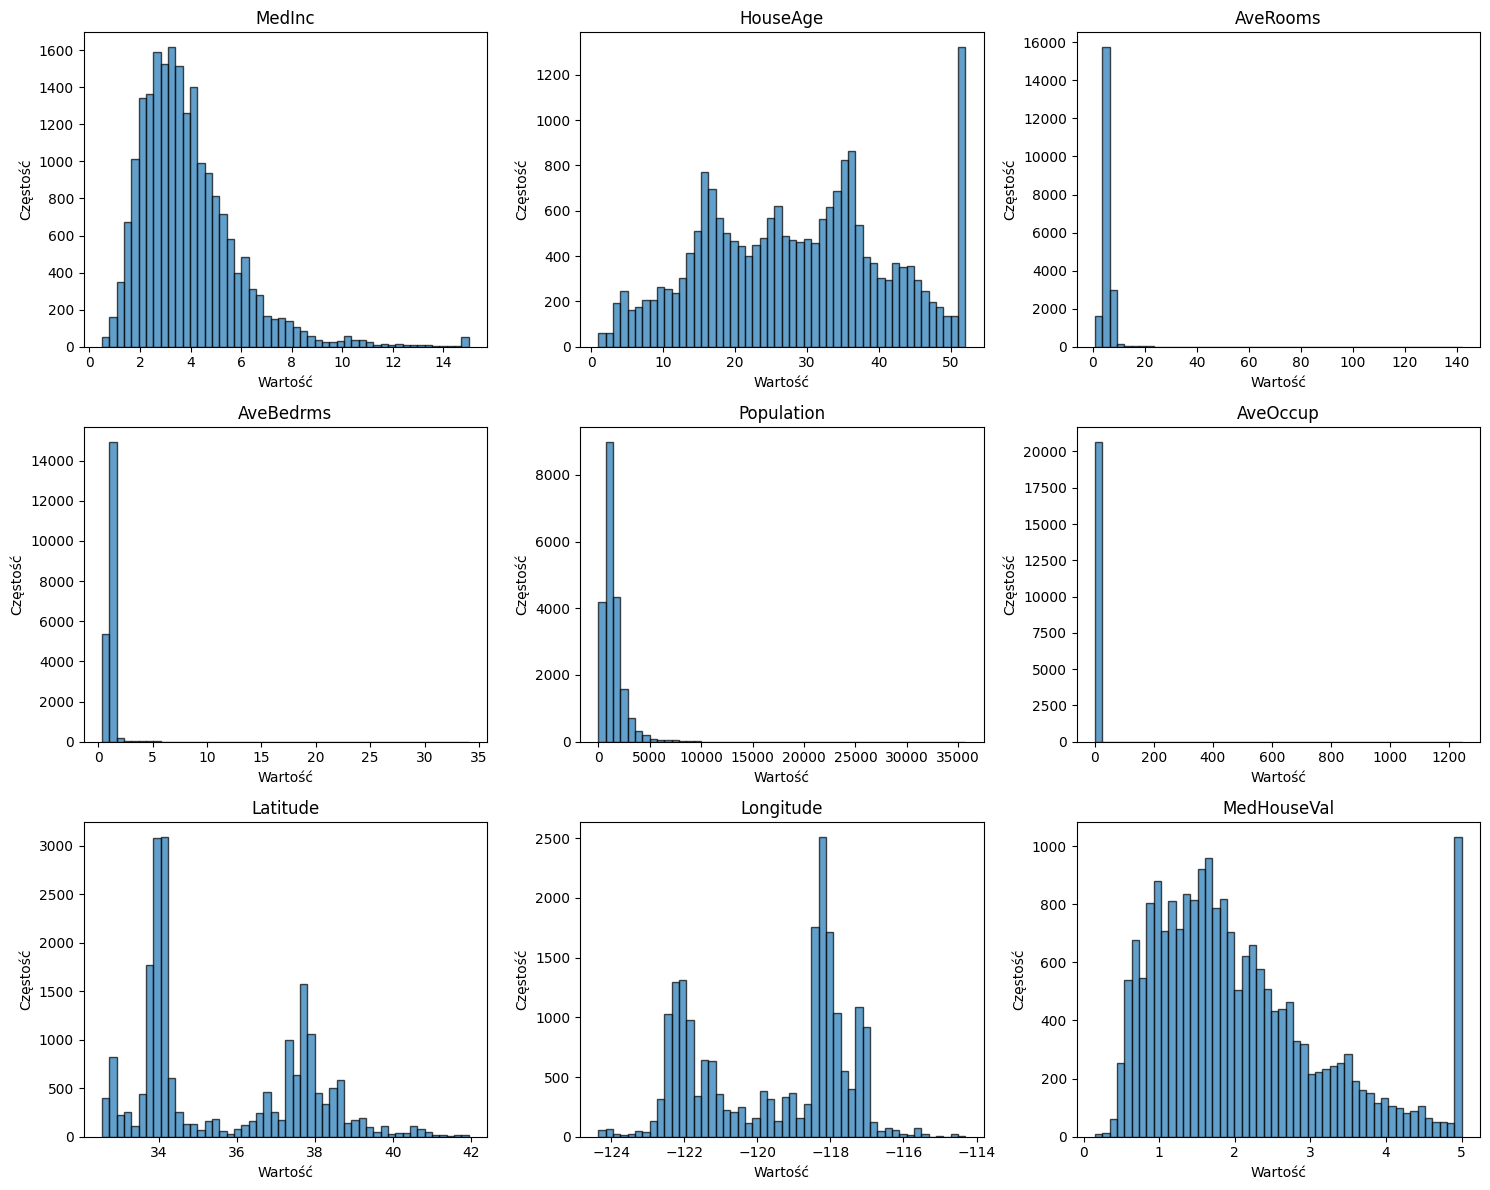


=== Korelacja cech z ceną domu ===
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: MedHouseVal, dtype: float64


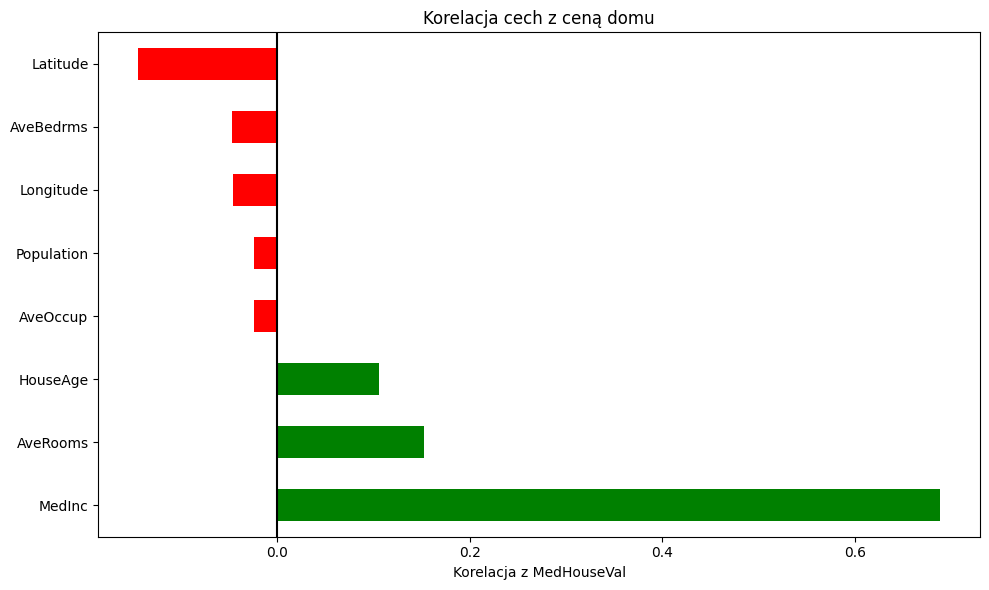

In [8]:
# Eksploracja California Housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Wczytanie danych
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target # Target: mediana wartości domu (w$100k)

print("=== California Housing Dataset ===")
print(f"Rozmiar: {df.shape}")
print(f"\nOpis cech:")
print(housing.DESCR[:1000])
print("\n=== Statystyki opisowe ===")
print(df.describe())


# Wizualizacja rozkładów
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for idx, col in enumerate(df.columns):
    axes[idx].hist(df[col], bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(col)
    axes[idx].set_xlabel('Wartość')
    axes[idx].set_ylabel('Częstość')
plt.tight_layout()
plt.show()


# Korelacja z targetem
correlations = df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False)
print("\n=== Korelacja cech z ceną domu ===")
print(correlations)


# Wizualizacja korelacji
plt.figure(figsize=(10, 6))
correlations.plot(kind='barh', color=['green' if x > 0 else 'red' for x in
correlations])
plt.xlabel('Korelacja z MedHouseVal')
plt.title('Korelacja cech z ceną domu')
plt.axvline(x=0, color='black', linestyle='-')
plt.tight_layout()
plt.show()

Pełny Pipeline: od danych do modelu

=== 1. Wczytanie danych ===
Liczba obserwacji: 20640
Liczba cech: 8
Cechy: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

=== 2. Podział danych ===
Train: 16512, Test: 4128

=== 3. Tworzenie pipeline ===

=== 4. Trening modelu ===
Liczba iteracji: 6

=== 5. Ewaluacja ===
Train MSE: 25624524395845846564864.0000
Test MSE: 597216466054831407104.0000
Train MAE: 10645942151.7183
Test MAE: 8719640955.4871
Train R²: -19168867482919663304704.0000
Test R²: -455748148838645825536.0000


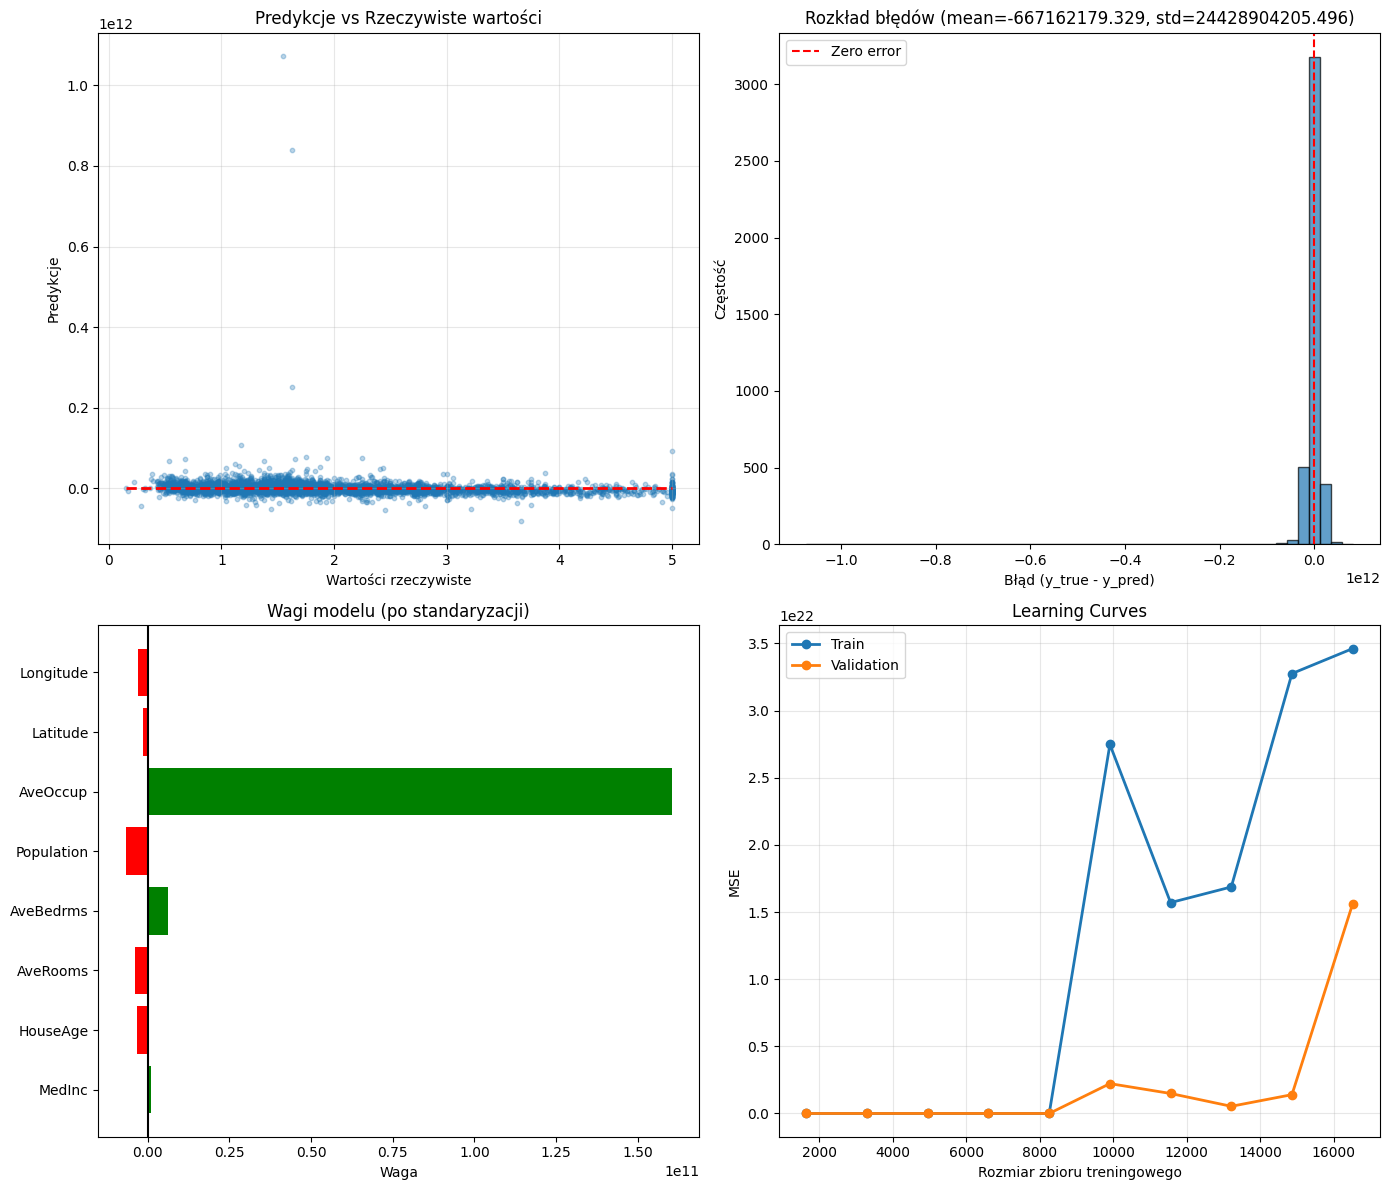


=== Podsumowanie ===
Model osiągnął R² = -455748148838645825536.0000 na zbiorze testowym
Średni błąd predykcji: $871964095548711


In [9]:
# Kompletny przykład z California Housing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# 1. WCZYTANIE DANYCH
print("=== 1. Wczytanie danych ===")
housing = fetch_california_housing()
X, y = housing.data, housing.target
feature_names = housing.feature_names

print(f"Liczba obserwacji: {len(y)}")
print(f"Liczba cech: {len(feature_names)}")
print(f"Cechy: {feature_names}")

# 2. PODZIAŁ DANYCH
print("\n=== 2. Podział danych ===")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

# 3. PREPROCESSING I MODEL
print("\n=== 3. Tworzenie pipeline ===")
pipeline = Pipeline([
('scaler', StandardScaler()),
('model', SGDRegressor(
    learning_rate='constant',
    eta0=0.01,
    max_iter=1000,
    tol=1e-4,
    random_state=42
    ))
])


# 4. TRENING
print("\n=== 4. Trening modelu ===")
pipeline.fit(X_train, y_train)
print(f"Liczba iteracji: {pipeline.named_steps['model'].n_iter_}")

# 5. EWALUACJA
print("\n=== 5. Ewaluacja ===")
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

metrics = {
'Train MSE': mean_squared_error(y_train, y_pred_train),
'Test MSE': mean_squared_error(y_test, y_pred_test),
'Train MAE': mean_absolute_error(y_train, y_pred_train),
'Test MAE': mean_absolute_error(y_test, y_pred_test),
'Train R²': r2_score(y_train, y_pred_train),
'Test R²': r2_score(y_test, y_pred_test),
}
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")


# 6. WIZUALIZACJA
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# a) Predykcje vs Rzeczywiste
axes[0, 0].scatter(y_test, y_pred_test, alpha=0.3, s=10)
axes[0, 0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
axes[0, 0].set_xlabel('Wartości rzeczywiste')
axes[0, 0].set_ylabel('Predykcje')
axes[0, 0].set_title('Predykcje vs Rzeczywiste wartości')
axes[0, 0].grid(True, alpha=0.3)

# b) Rozkład błędów
errors = y_test - y_pred_test
axes[0, 1].hist(errors, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='red', linestyle='--', label='Zero error')
axes[0, 1].set_xlabel('Błąd (y_true - y_pred)')
axes[0, 1].set_ylabel('Częstość')
axes[0, 1].set_title(f'Rozkład błędów (mean={errors.mean():.3f}, std={errors.std():.3f})')
axes[0, 1].legend()

# c) Wagi modelu
weights = pipeline.named_steps['model'].coef_
axes[1, 0].barh(feature_names, weights, color=['green' if w > 0 else 'red' for w in weights])
axes[1, 0].set_xlabel('Waga')
axes[1, 0].set_title('Wagi modelu (po standaryzacji)')
axes[1, 0].axvline(x=0, color='black', linestyle='-')

# d) Learning curve
train_sizes, train_scores, val_scores = learning_curve(
pipeline, X, y, train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
train_mse = -train_scores.mean(axis=1)
val_mse = -val_scores.mean(axis=1)
axes[1, 1].plot(train_sizes, train_mse, 'o-', label='Train', linewidth=2)
axes[1, 1].plot(train_sizes, val_mse, 'o-', label='Validation', linewidth=2)
axes[1, 1].set_xlabel('Rozmiar zbioru treningowego')
axes[1, 1].set_ylabel('MSE')
axes[1, 1].set_title('Learning Curves')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("\n=== Podsumowanie ===")
print(f"Model osiągnął R² = {metrics['Test R²']:.4f} na zbiorze testowym")
print(f"Średni błąd predykcji: ${metrics['Test MAE']*100000:.0f}")
